In [46]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import adjusted_rand_score
import geopandas as gpd

warnings.filterwarnings("ignore")
seed = 42
np.random.seed(seed)

plt.rc('font', size=16)
plt.rc('axes', titlesize=18)
plt.rc('axes', labelsize=15)
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)
plt.rc('legend', fontsize=15)
plt.rc('legend', title_fontsize=16)

In [47]:
import sys
from pathlib import Path
if str(Path.cwd().parent) not in sys.path:
    sys.path.append(str(Path.cwd().parent))

# Built functions
from base import RKM, CDPCA, DGRC

In [ ]:
owid_df = pd.read_csv("owid_data.csv")
owid_df.head()

,Entity,Code,life-expectancy,child-mortality,incidence-of-tuberculosis-sdgs,share-of-adults-who-smoke,total-alcohol-consumption-per-capita-litres-of-pure-alcohol,share-of-adults-defined-as-obese,prevalence-of-undernourishment,proportion-using-safely-managed-drinking-water,physicians-per-1000-people,nurses-and-midwives-per-1000-people,hospital-beds-per-1000-people,share-of-children-immunized-dtp3,total-healthcare-expenditure-gdp,share-of-out-of-pocket-expenditure-on-healthcare,population,gdp-per-capita-worldbank
0,China,CHN,77.9396,0.80,58.0,24.3,5.73,6.932614,2.5,67.560629,2.255,3.123,4.82,99.0,5.265169,35.230020,1423520357,18820.5140
1,India,IND,70.7463,3.43,202.0,31.6,4.92,6.068963,11.8,67.933365,0.889,1.700,1.62,91.0,2.952998,52.004210,1389030307,7930.0913
2,United States,USA,78.9160,0.65,2.9,22.0,9.57,40.416073,2.5,97.009330,3.482,13.020,2.72,94.0,16.544860,11.308729,337790069,69112.6000
3,Indonesia,IDN,70.3491,2.36,312.0,32.0,0.11,9.024028,6.4,29.487108,0.462,3.781,1.16,85.0,2.878629,34.550010,272489381,12757.7850
4,Pakistan,PAK,66.7288,6.67,263.0,23.6,0.10,18.229230,12.9,44.656890,1.049,0.453,0.50,84.0,2.847369,56.083010,230800908,5295.9530


In [49]:
identifiers = owid_df[['Entity', 'Code']]
# We drop Entity and Code to isolate the purely numerical N x P matrix
features = owid_df.drop(columns=['Entity', 'Code'])

# Standardise data
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
K=4


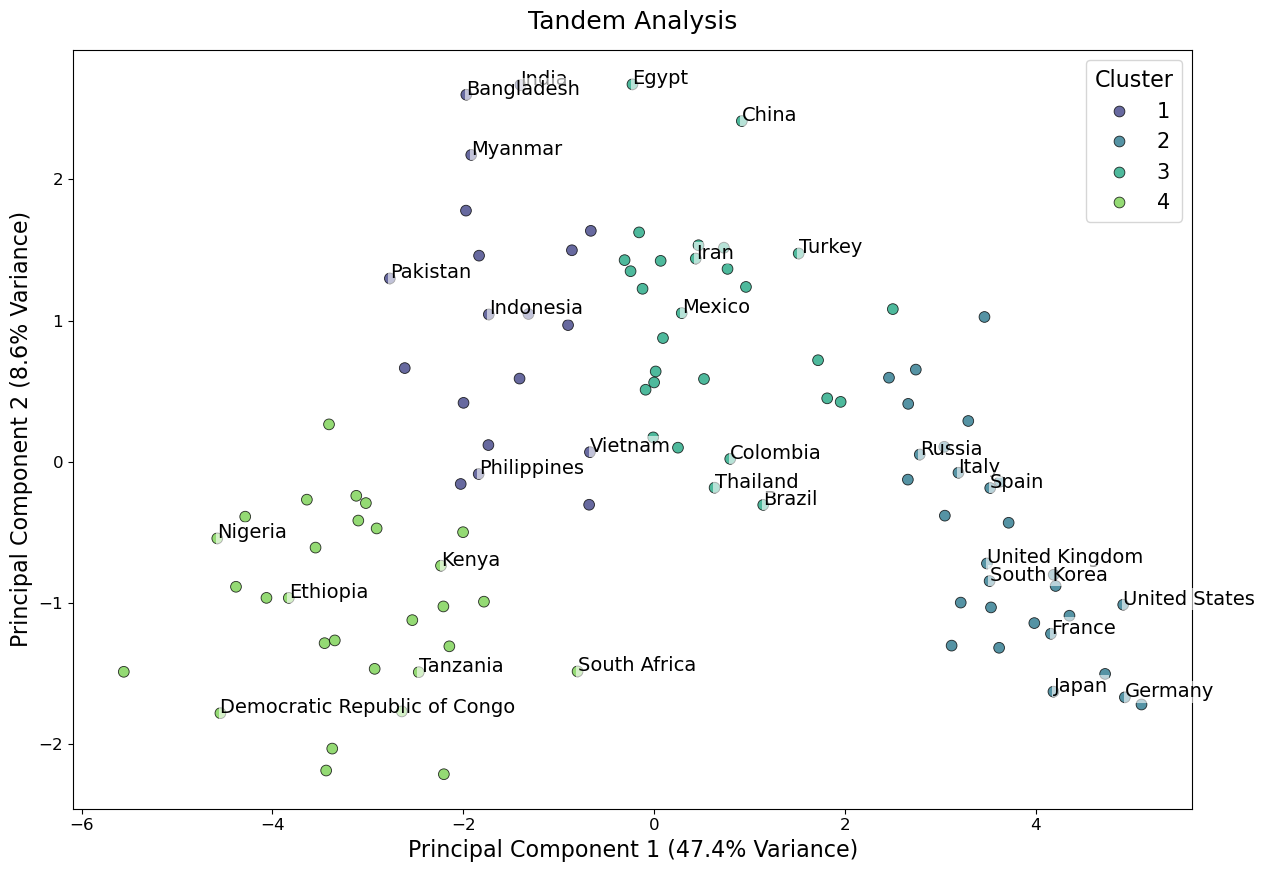

PCA Loadings


,PC1,PC2
life-expectancy,0.333500,0.138400
child-mortality,-0.310200,-0.200500
incidence-of-tuberculosis-sdgs,-0.226400,-0.186600
share-of-adults-who-smoke,0.152000,0.239300
total-alcohol-consumption-per-capita-litres-of-pure-alcohol,0.209700,-0.394800
share-of-adults-defined-as-obese,0.208500,0.232500
prevalence-of-undernourishment,-0.244400,-0.349100
proportion-using-safely-managed-drinking-water,0.287500,0.082500
physicians-per-1000-people,0.314000,-0.029600
nurses-and-midwives-per-1000-people,0.309700,-0.191500


In [51]:
# Tandem analysis
pca = PCA(n_components=2)
pcs = pca.fit_transform(features_scaled)

# Store the Principal Components
tandem_pc_df = pd.DataFrame(data=pcs, columns=['PC1', 'PC2'])
tandem_pc_df['Entity'] = identifiers['Entity'].values

# K-means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
tandem_pc_df['Cluster'] = kmeans.fit_predict(pcs)+1
tandem_pc_df['Cluster'] = tandem_pc_df['Cluster'].astype(str)

# Plot
plt.figure(figsize=(13, 9))

# Create the scatter plot
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster',
    hue_order=[str(i) for i in range(1, K + 1)],
    palette='viridis',
    data=tandem_pc_df,
    s=60,
    alpha=0.8,
    edgecolor='k'
)

# Annotate names
num_labels = 30
tandem_pc_df['population'] = owid_df['population'].values
top_countries = tandem_pc_df.nlargest(num_labels, 'population')['Entity'].tolist()
for idx, row in tandem_pc_df.iterrows():
    if row['Entity'] in top_countries:
        plt.text(row['PC1'], row['PC2'], row['Entity'], 
                 fontsize=14,
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

# Format the plot
variance_1 = pca.explained_variance_ratio_[0] * 100
variance_2 = pca.explained_variance_ratio_[1] * 100

plt.title('Tandem Analysis', pad=15, fontsize=18)
plt.xlabel(f'Principal Component 1 ({variance_1:.1f}% Variance)', fontsize=16)
plt.ylabel(f'Principal Component 2 ({variance_2:.1f}% Variance)', fontsize=16)
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig("application-tandem.pdf", format='pdf', bbox_inches='tight')
plt.show()

loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=features.columns
)

# Display the raw matrix
print("PCA Loadings")
loadings.round(4).style

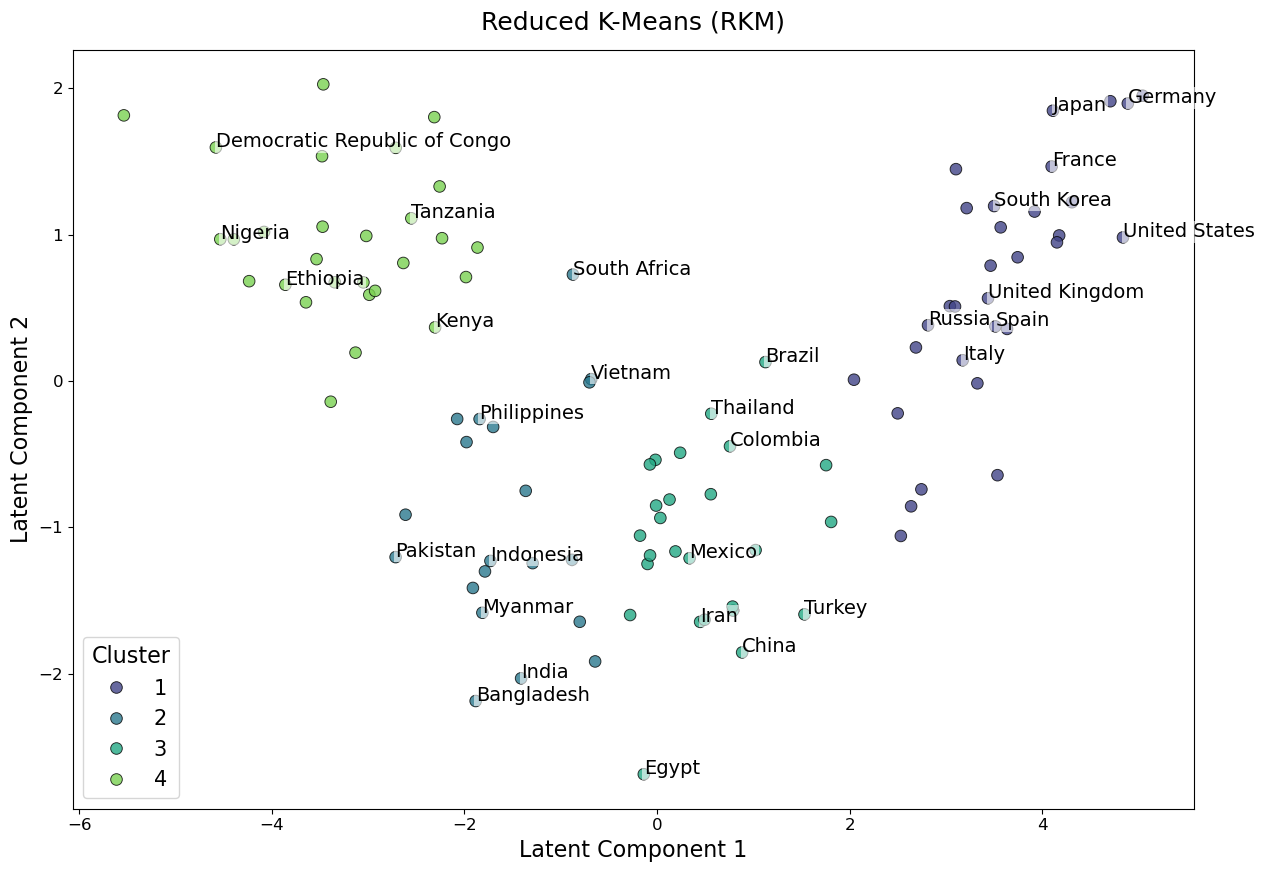

RKM Loading matrix


,LC1,LC2
life-expectancy,0.3369,-0.2088
child-mortality,-0.3067,0.3518
incidence-of-tuberculosis-sdgs,-0.2303,0.0565
share-of-adults-who-smoke,0.1640,-0.0917
total-alcohol-consumption-per-capita-litres-of-pure-alcohol,0.2004,0.4417
share-of-adults-defined-as-obese,0.2238,-0.3047
prevalence-of-undernourishment,-0.2552,0.3372
proportion-using-safely-managed-drinking-water,0.2859,-0.0505
physicians-per-1000-people,0.3316,0.1254
nurses-and-midwives-per-1000-people,0.3023,0.1783


In [53]:
rkm_model = RKM(K=4, L=2, Rndstart=50, maxiter=300, Rndstate=seed)
rkm_model.fit(features_scaled)

# Predictions
if rkm_model.U.ndim > 1:
    preds_rkm = np.argmax(rkm_model.U, axis=1) + 1
else:
    preds_rkm = rkm_model.U.flatten() + 1

# Project data onto the latent space
X_rkm_proj = features_scaled @ rkm_model.A

# Store projections
rkm_proj_df = pd.DataFrame(data=X_rkm_proj, columns=['LC1', 'LC2'])
rkm_proj_df['Entity'] = identifiers['Entity'].values
rkm_proj_df['Cluster'] = preds_rkm.astype(str)

# Plot
plt.figure(figsize=(13, 9))

# Create the scatter plot
sns.scatterplot(
    x='LC1', y='LC2',
    hue='Cluster',
    hue_order=[str(i) for i in range(1, K + 1)],
    palette='viridis',
    data=rkm_proj_df,
    s=70,
    alpha=0.8,
    edgecolor='k'
)

# Annotate names
num_labels = 30
rkm_proj_df['population'] = owid_df['population'].values
top_countries = rkm_proj_df.nlargest(num_labels, 'population')['Entity'].tolist()

for idx, row in rkm_proj_df.iterrows():
    if row['Entity'] in top_countries:
        # Added a slight shadow/bbox to make text readable over data points
        plt.text(row['LC1'], row['LC2'], row['Entity'], 
                 fontsize=14,
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

# Format the plot
plt.title('Reduced K-Means (RKM)', pad=15, fontsize=18)
plt.xlabel('Latent Component 1', fontsize=16)
plt.ylabel('Latent Component 2', fontsize=16)
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig("application-rkm.pdf", format='pdf', bbox_inches='tight')
plt.show()

#  Extract loadings
loadings_rkm = pd.DataFrame(
    rkm_model.A, 
    columns=['LC1', 'LC2'], 
    index=features.columns
)

print("RKM Loading matrix")
loadings_rkm.round(4)

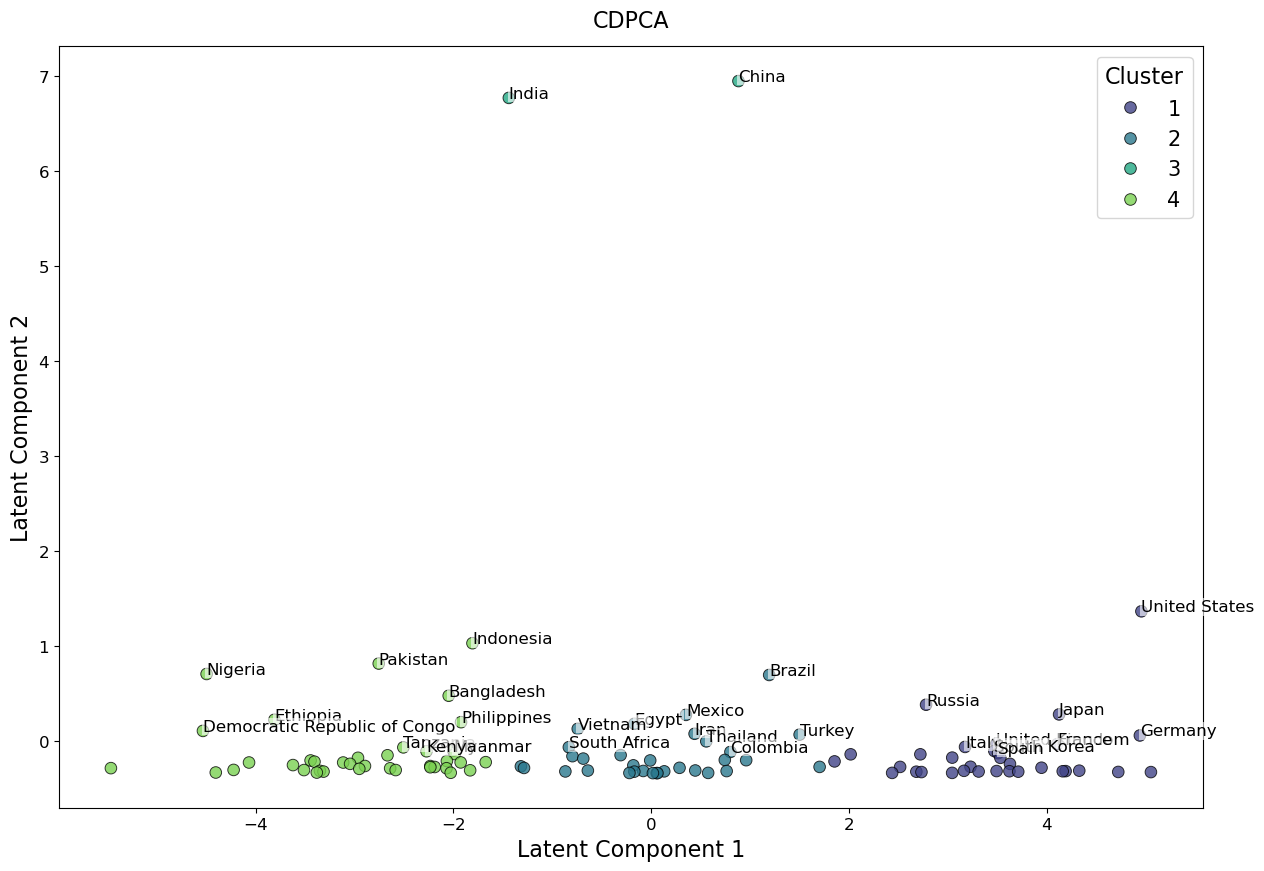

CDPCA Loading matrix


,LC1,LC2
life-expectancy,0.3302,0.0
child-mortality,-0.2996,0.0
incidence-of-tuberculosis-sdgs,-0.2374,0.0
share-of-adults-who-smoke,0.1391,0.0
total-alcohol-consumption-per-capita-litres-of-pure-alcohol,0.2082,0.0
share-of-adults-defined-as-obese,0.2392,0.0
prevalence-of-undernourishment,-0.2332,0.0
proportion-using-safely-managed-drinking-water,0.2869,0.0
physicians-per-1000-people,0.3298,0.0
nurses-and-midwives-per-1000-people,0.2996,0.0


In [54]:
cdpca_model = CDPCA(K=4, L=2, Rndstart=60, maxiter=300, Rndstate=seed)
cdpca_model.fit(features_scaled)

# Extract predictions
if cdpca_model.U.ndim > 1:
    preds_cdpca = np.argmax(cdpca_model.U, axis=1) + 1
else:
    preds_cdpca = cdpca_model.U.flatten() + 1

# Project data onto the latent space
X_cdpca_proj = features_scaled @ cdpca_model.A

# Store projections
cdpca_proj_df = pd.DataFrame(data=X_cdpca_proj, columns=['LC1', 'LC2'])
cdpca_proj_df['Entity'] = identifiers['Entity'].values
cdpca_proj_df['Cluster'] = preds_cdpca.astype(str)

# Plot
plt.figure(figsize=(13, 9))

# Create the scatter plot
sns.scatterplot(
    x='LC1', y='LC2',
    hue='Cluster',
    hue_order=[str(i) for i in range(1, K + 1)],
    palette='viridis',
    data=cdpca_proj_df,
    s=70,
    alpha=0.8,
    edgecolor='k'
)

# Annotate names
num_labels = 30
cdpca_proj_df['population'] = owid_df['population'].values
top_countries = cdpca_proj_df.nlargest(num_labels, 'population')['Entity'].tolist()

for idx, row in cdpca_proj_df.iterrows():
    if row['Entity'] in top_countries:
        # Added a slight shadow/bbox to make text readable over data points
        plt.text(row['LC1'], row['LC2'], row['Entity'], 
                 fontsize=12,
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

# Format the plot
plt.title('CDPCA', pad=14, fontsize=16)
plt.xlabel('Latent Component 1', fontsize=16)
plt.ylabel('Latent Component 2', fontsize=16)
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig("application-cdpca.pdf", format='pdf', bbox_inches='tight')
plt.show()

# Extract loadings
loadings_cdpca = pd.DataFrame(
    cdpca_model.A, 
    columns=['LC1', 'LC2'], 
    index=features.columns
)

print("CDPCA Loading matrix")
loadings_cdpca.round(4)

In [41]:
import itertools
from tqdm.auto import tqdm

## Cross val
L_d_vals = [0, 1, 2, 3, 4]
rho_1_vals = [2.5, 3.0, 3.5]
rho_2_vals = [0.5, 1.0, 1.5, 2.0]
rho_grid = [(r1, r2) for r1 in rho_1_vals for r2 in rho_2_vals if r1 > r2]
all_combs = [(L_d, r1, r2) for L_d in L_d_vals for r1, r2 in rho_grid]

best_loss = np.inf
best_params = None
for L_c in [2, 3]:
    for L_d, r1, r2 in tqdm(all_combs, desc=f"DGRC CV Search, L_c = {L_c}"):
        # Fit the model
        dgrc_model = DGRC(K=4, L=L_d+L_c, L_d=L_d, rho_1=r1, rho_2=r2, Rndstart=50, maxiter=150, Rndstate=seed)
        dgrc_model.fit(features_scaled)
        current_loss = dgrc_model.loss
        
        # Select parameters that minimise loss
        if current_loss < best_loss:
            best_loss = current_loss
            best_params = (L_d, r1, r2)
    print(f"Best Parameters for L_c={L_c},: (L_d, rho_1, rho_2)={best_params}")



DGRC CV Search, L_c = 2:   0%|          | 0/60 [00:00<?, ?it/s]

Best Parameters for L_c=2,: (L_d, rho_1, rho_2)=(4, 3.5, 0.5)


DGRC CV Search, L_c = 3:   0%|          | 0/60 [00:00<?, ?it/s]

Best Parameters for L_c=3,: (L_d, rho_1, rho_2)=(4, 3.5, 0.5)


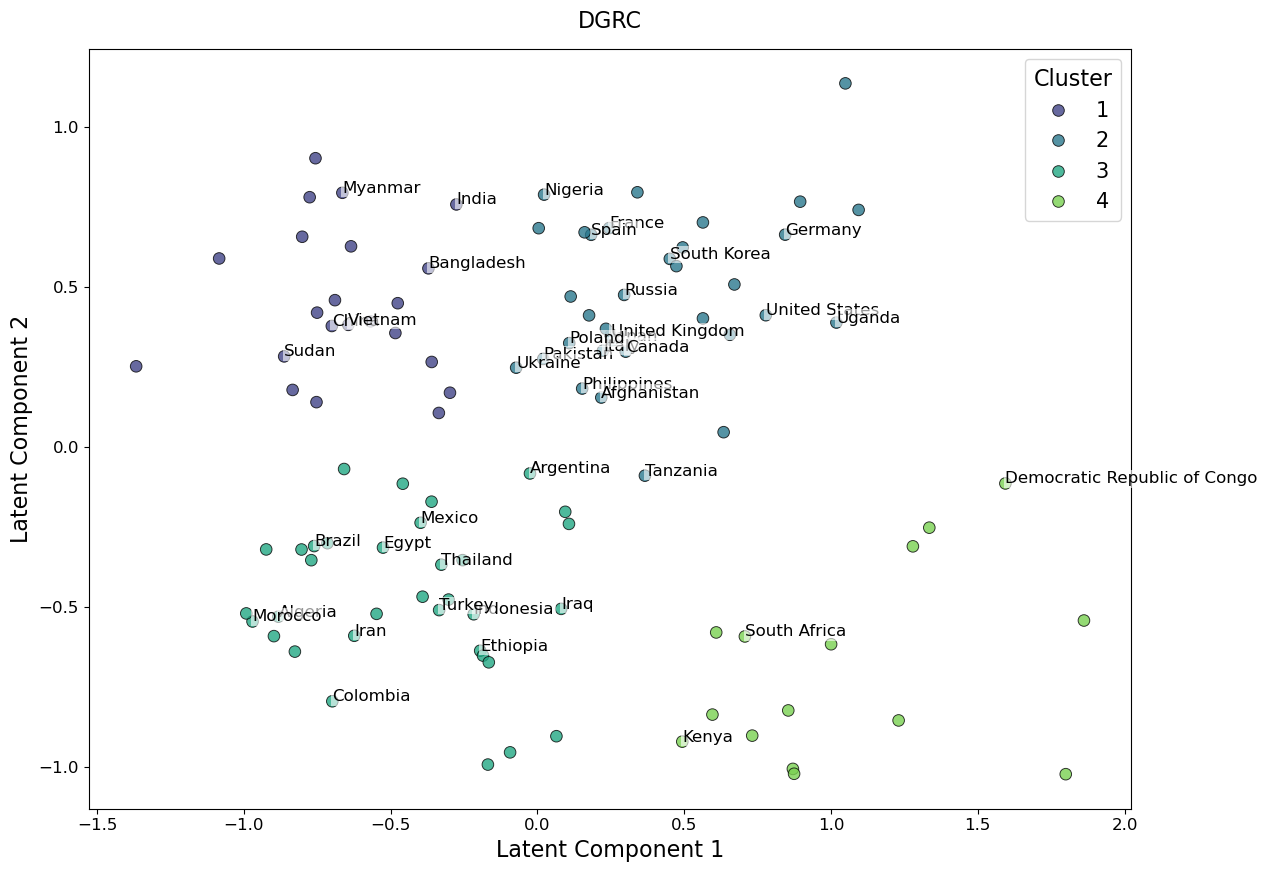

DGRC CLUSTER MEMBERSHIPS

Cluster 1 (22 countries):
Azerbaijan, Bangladesh, Benin, Burkina Faso, Cambodia, Cameroon, Chile, China
Dominican Republic, Guinea, India, Laos, Mali, Myanmar, Nepal, Niger, Serbia
Sudan, Tajikistan, Turkmenistan, Uzbekistan, Vietnam

Cluster 2 (34 countries):
Afghanistan, Angola, Australia, Austria, Belarus, Belgium, Bulgaria, Canada
Chad, Czechia, France, Germany, Greece, Hungary, Italy, Japan, Netherlands
Nigeria, Pakistan, Philippines, Poland, Portugal, Romania, Russia
Sierra Leone, South Korea, Spain, Sweden, Switzerland, Tanzania, Uganda
Ukraine, United Kingdom, United States

Cluster 3 (34 countries):
Algeria, Argentina, Bolivia, Brazil, Burundi, Colombia, Cote d'Ivoire, Ecuador
Egypt, Ethiopia, Ghana, Guatemala, Honduras, Indonesia, Iran, Iraq, Israel
Jordan, Kazakhstan, Kyrgyzstan, Libya, Malawi, Malaysia, Mexico, Morocco
Nicaragua, Paraguay, Peru, Senegal, Sri Lanka, Thailand, Togo, Tunisia, Turkey

Cluster 4 (15 countries):
Cuba, Democratic Republic

,LC1,LC2,LC3,LC4,LC5,LC6
life-expectancy,0.0000,0.4495,-0.0943,0.1630,0.0994,0.3080
child-mortality,0.0000,0.6923,-0.0418,0.0305,-0.2495,-0.3541
incidence-of-tuberculosis-sdgs,0.3082,0.0000,0.2860,-0.2995,0.1817,-0.2386
share-of-adults-who-smoke,0.0000,0.1735,0.5487,-0.0863,0.5317,0.1408
total-alcohol-consumption-per-capita-litres-of-pure-alcohol,0.0000,0.3680,0.1672,-0.3891,-0.2591,0.1856
share-of-adults-defined-as-obese,0.1316,0.0000,0.1438,0.5786,0.0542,0.2065
prevalence-of-undernourishment,0.6826,0.0000,-0.0250,0.0117,-0.0930,-0.2689
proportion-using-safely-managed-drinking-water,-0.0387,0.0000,0.0955,0.0513,0.0776,0.2900
physicians-per-1000-people,0.1770,0.0000,0.0924,0.0518,0.0321,0.3081
nurses-and-midwives-per-1000-people,0.0000,0.1885,-0.0001,-0.1265,-0.1367,0.2976


In [55]:
# Fit model
dgrc_model = DGRC(K=4, L=6, L_d=4, rho_1=3.5, rho_2=0.5, Rndstart=50, maxiter=300, Rndstate=seed)
dgrc_model.fit(features_scaled)

# Extract predictions
if dgrc_model.U.ndim > 1:
    preds_dgrc = np.argmax(dgrc_model.U, axis=1) + 1
else:
    preds_dgrc = dgrc_model.U.flatten() + 1

# Project data onto the latent space
X_dgrc_proj = features_scaled @ dgrc_model.A

# Store projections
dgrc_proj_df = pd.DataFrame(data=X_dgrc_proj, columns=[f'LC{i+1}' for i in range(dgrc_model.A.shape[1])])
dgrc_proj_df['Entity'] = identifiers['Entity'].values
dgrc_proj_df['Cluster'] = preds_dgrc.astype(str)

# Plot
plt.figure(figsize=(13, 9))

# Create the scatter plot
sns.scatterplot(
    x='LC1', y='LC2',
    hue='Cluster',
    hue_order=[str(i) for i in range(1, K + 1)],
    palette='viridis',
    data=dgrc_proj_df,
    s=70,
    alpha=0.8,
    edgecolor='k'
)

# Annotate names
num_labels = 40
dgrc_proj_df['population'] = owid_df['population'].values
top_countries = dgrc_proj_df.nlargest(num_labels, 'population')['Entity'].tolist()

for idx, row in dgrc_proj_df.iterrows():
    if row['Entity'] in top_countries:
        # Added a slight shadow/bbox to make text readable over data points
        plt.text(row['LC1'], row['LC2'], row['Entity'], 
                 fontsize=12,
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

# Format the plot
plt.title('DGRC', pad=15, fontsize=16)
plt.xlabel('Latent Component 1', fontsize=16)
plt.ylabel('Latent Component 2', fontsize=16)
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig("application-dgrc.pdf", format='pdf', bbox_inches='tight')
plt.show()

# Extract loadings
loadings_dgrc = pd.DataFrame(
    dgrc_model.A, 
    columns=[f'LC{i+1}' for i in range(dgrc_model.A.shape[1])], 
    index=features.columns
)


print("DGRC CLUSTER MEMBERSHIPS")
# Loop through each cluster (1 to K)
for cluster_id in range(1, K + 1):
    members = dgrc_proj_df[dgrc_proj_df['Cluster'] == str(cluster_id)]['Entity'].sort_values().tolist()
    print(f"\nCluster {cluster_id} ({len(members)} countries):")

    current_line = ""
    for country in members:
        if len(current_line) + len(country) + 2 > 80:
            print(current_line.rstrip(", "))
            current_line = country + ", "
        else:
            current_line += country + ", "

    if current_line:
        print(current_line.rstrip(", "))

print("\nDGRC Loading matrix")
loadings_dgrc.round(4).head(16)


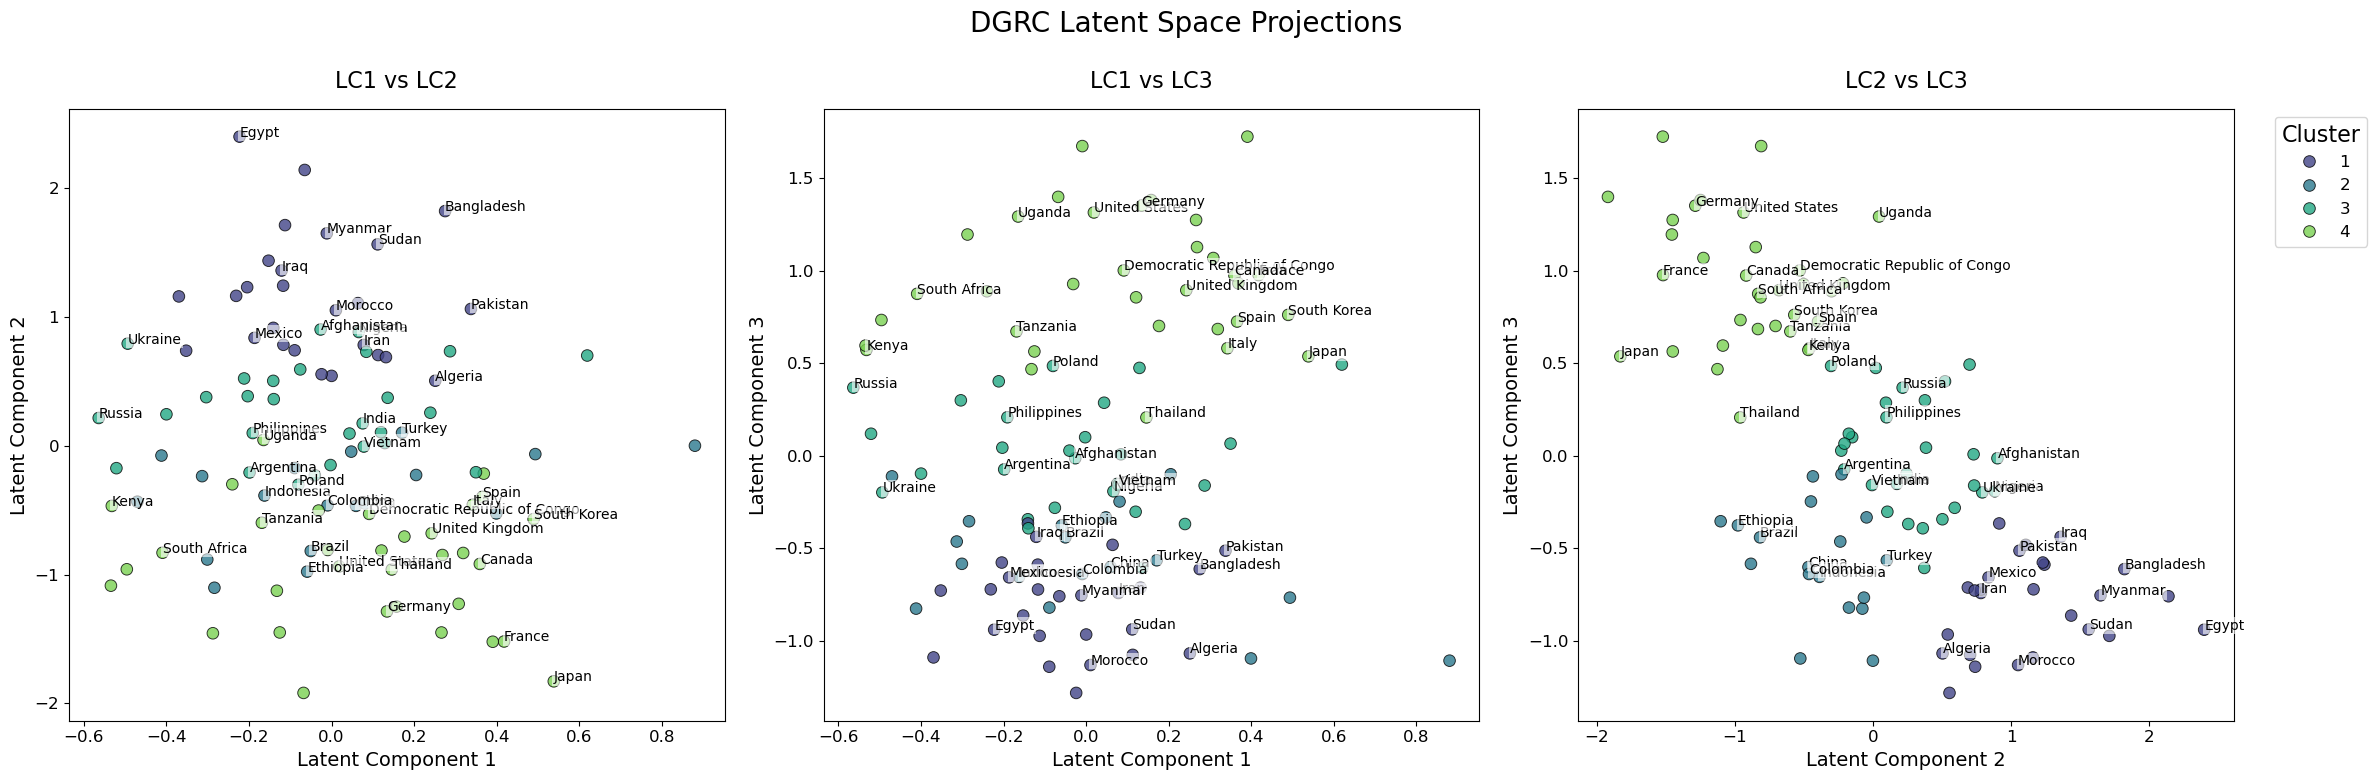

DGRC CLUSTER MEMBERSHIPS

Cluster 1 (26 countries):
Algeria, Azerbaijan, Bangladesh, Cambodia, Cameroon, Egypt, Guatemala
Honduras, Iran, Iraq, Jordan, Kyrgyzstan, Mexico, Morocco, Myanmar, Nepal
Pakistan, Paraguay, Senegal, Sri Lanka, Sudan, Tajikistan, Togo, Tunisia
Turkmenistan, Uzbekistan

Cluster 2 (18 countries):
Bolivia, Brazil, Burkina Faso, Burundi, China, Colombia, Cote d'Ivoire
Ecuador, Ethiopia, Ghana, Guinea, Indonesia, Laos, Libya, Malawi, Mali, Niger
Turkey

Cluster 3 (28 countries):
Afghanistan, Argentina, Belarus, Benin, Bulgaria, Chad, Chile
Dominican Republic, Greece, Hungary, India, Israel, Kazakhstan, Malaysia
Nicaragua, Nigeria, Peru, Philippines, Poland, Portugal, Russia, Saudi Arabia
Serbia, Sierra Leone, Syria, Ukraine, Venezuela, Vietnam

Cluster 4 (33 countries):
Angola, Australia, Austria, Belgium, Canada, Cuba, Czechia
Democratic Republic of Congo, France, Germany, Haiti, Italy, Japan, Kenya
Madagascar, Mozambique, Netherlands, Papua New Guinea, Romania, Rw

,LC1,LC2,LC3,LC4,LC5,LC6,LC7
life-expectancy,0.7400,0.0000,0.0000,-0.1452,-0.1741,0.0208,0.3297
child-mortality,0.6585,0.0000,0.0000,0.1682,0.2313,-0.0606,-0.3209
incidence-of-tuberculosis-sdgs,0.0000,0.0000,0.2627,0.1678,-0.2234,0.2968,-0.2572
share-of-adults-who-smoke,0.0502,0.0000,0.0000,0.3449,-0.5187,0.4870,0.1541
total-alcohol-consumption-per-capita-litres-of-pure-alcohol,0.0000,0.0000,0.2954,0.2969,0.3470,0.1321,0.1781
share-of-adults-defined-as-obese,0.0000,0.4017,0.0000,-0.0404,-0.4369,-0.3549,0.2401
prevalence-of-undernourishment,0.0000,0.0000,0.6277,-0.0564,-0.1188,-0.1186,-0.3103
proportion-using-safely-managed-drinking-water,0.0000,0.0000,0.1392,-0.0405,-0.1770,0.0131,0.2773
physicians-per-1000-people,-0.1275,0.0000,0.0000,0.1616,-0.0203,-0.0008,0.3169
nurses-and-midwives-per-1000-people,0.0000,-0.2068,0.0000,0.1338,0.1737,0.0243,0.2949


In [65]:
# Fit model
dgrc_model = DGRC(K=4, L=7, L_d=4, rho_1=3.5, rho_2=0.5, Rndstart=50, maxiter=300, Rndstate=seed)
dgrc_model.fit(features_scaled)

# Extract predictions
if dgrc_model.U.ndim > 1:
    preds_dgrc = np.argmax(dgrc_model.U, axis=1) + 1
else:
    preds_dgrc = dgrc_model.U.flatten() + 1

# Project data onto the latent space
X_dgrc_proj = features_scaled @ dgrc_model.A

# Store projections
dgrc_proj_df = pd.DataFrame(data=X_dgrc_proj, columns=[f'LC{i+1}' for i in range(dgrc_model.A.shape[1])])
dgrc_proj_df['Entity'] = identifiers['Entity'].values
dgrc_proj_df['Cluster'] = preds_dgrc.astype(str)

# Plot
component_pairs = [('LC1', 'LC2'), ('LC1', 'LC3'), ('LC2', 'LC3')]
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for ax, (x_col, y_col) in zip(axes, component_pairs):
    
    sns.scatterplot(
        x=x_col, y=y_col,
        hue='Cluster',
        hue_order=[str(i) for i in range(1, K + 1)],
        palette='viridis',
        data=dgrc_proj_df,
        s=70,
        alpha=0.8,
        edgecolor='k',
        ax=ax,
        legend=(ax == axes[2]) 
    )

    for idx, row in dgrc_proj_df.iterrows():
        if row['Entity'] in top_countries:
            ax.text(row[x_col], row[y_col], row['Entity'], 
                     fontsize=10, 
                     bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

    ax.set_title(f'{x_col} vs {y_col}', pad=15, fontsize=16)
    ax.set_xlabel(f'Latent Component {x_col[-1]}', fontsize=14)
    ax.set_ylabel(f'Latent Component {y_col[-1]}', fontsize=14)

fig.suptitle('DGRC Latent Space Projections', fontsize=20)
axes[2].legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.savefig("application-dgrc_L_3.pdf", format='pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()


# Extract loadings
loadings_dgrc = pd.DataFrame(
    dgrc_model.A, 
    columns=[f'LC{i+1}' for i in range(dgrc_model.A.shape[1])], 
    index=features.columns
)


print("DGRC CLUSTER MEMBERSHIPS")
# Loop through each cluster (1 to K)
for cluster_id in range(1, K + 1):
    members = dgrc_proj_df[dgrc_proj_df['Cluster'] == str(cluster_id)]['Entity'].sort_values().tolist()
    print(f"\nCluster {cluster_id} ({len(members)} countries):")

    current_line = ""
    for country in members:
        if len(current_line) + len(country) + 2 > 80:
            print(current_line.rstrip(", "))
            current_line = country + ", "
        else:
            current_line += country + ", "

    if current_line:
        print(current_line.rstrip(", "))

print("\nDGRC Loading matrix")
loadings_dgrc.round(4).head(16)


In [ ]:
# Load the map directly from the official Natural Earth URL
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

world = world.rename(columns={'NAME': 'name'})
world = world[world.name != "Antarctica"]

name_mapping = {
    'United States': 'United States of America'
}
dgrc_proj_df['Entity'] = dgrc_proj_df['Entity'].replace(name_mapping)

# Merge geometries with your projection data
world_merged = world.merge(dgrc_proj_df, how="left", left_on="name", right_on="Entity")

# Set up the matplotlib figure
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot the choropleth map
world_merged.plot(
    column='Cluster',             
    ax=ax,
    categorical=True,             
    cmap='viridis',               
    edgecolor='black',            
    linewidth=0.4,                
    legend=True,
    legend_kwds={
        'title': 'Cluster',
        'loc': 'lower left', 
        'fontsize': 12,
        'title_fontsize': 14
    },
    missing_kwds={
        'color': '#d3d3d3',
        'edgecolor': 'white',     
        'label': 'No Data'
    }
)

# Format the plot for your document
ax.set_axis_off()                 
plt.title('DGRC Cluster Memberships Map', fontsize=18, pad=20)

# Save as a high-res vector graphic for LaTeX
plt.savefig('dgrc_cluster_map.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()